
Загрузка обработанного датасета
Shape: (1000, 7)
   Storage_Capacity  Screen_Size    Weight  Processor_Speed  RAM_Size   Brand  \
0               512    11.185147  2.641094         3.830296        16    Asus   
1              1000    11.311372  3.260012         2.912833         4    Acer   
2               256    11.853023  2.029061         3.241627         4  Lenovo   
3               512    12.280360  4.573865         3.806248        16    Acer   
4              1000    14.990877  4.193472         3.268097        32    Acer   

          Price  
0  17395.093065  
1  31607.605919  
2   9291.023542  
3  17436.728334  
4  32917.990718  
Storage_Capacity      int64
Screen_Size         float64
Weight              float64
Processor_Speed     float64
RAM_Size              int64
Brand                object
Price               float64
dtype: object

ВЕРСИЯ 1. MLP-регрессор

Метрики качества библиотечной модели
MSE:  384138.09
RMSE: 619.79
MAE:  486.75
R2:   0.9958

Первые 10 предсказаний биб

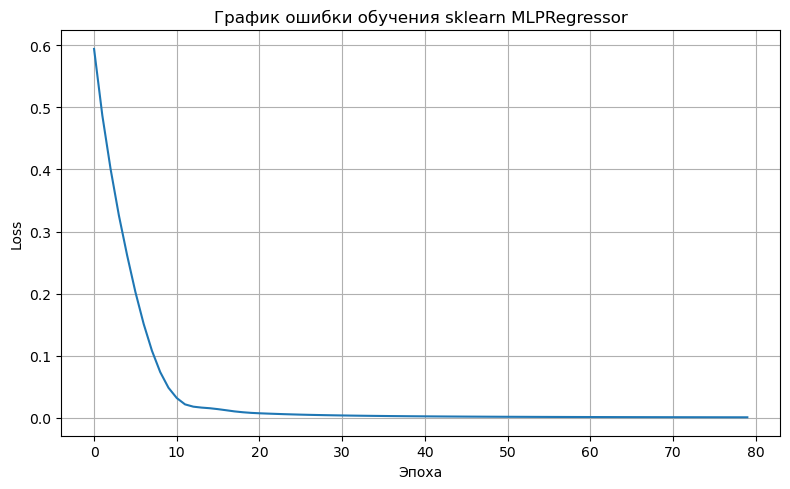


ВЕРСИЯ 2. Ручная реализация MLP-регрессора
Epoch 0, MSE: 0.198208
Epoch 100, MSE: 0.005583
Epoch 200, MSE: 0.003367
Epoch 300, MSE: 0.002474
Epoch 400, MSE: 0.002028
Epoch 500, MSE: 0.001699
Epoch 600, MSE: 0.001492
Epoch 700, MSE: 0.001383
Epoch 800, MSE: 0.001207
Epoch 900, MSE: 0.001164

Метрики качества ручной модели
MSE:  250044.75
RMSE: 500.04
MAE:  394.21
R2:   0.9972

Первые 10 предсказаний ручной модели:
     Real Price  Predicted Price
0  10900.502075     10335.957656
1  31727.516697     30899.566714
2   9636.022750      9887.996689
3   9412.599857      9238.178114
4  31641.105861     32130.505485
5  31832.486943     31675.287358
6  10438.451568     10179.275070
7  17205.205679     18126.174113
8  18743.569392     18550.312628
9  32342.705862     31990.485701


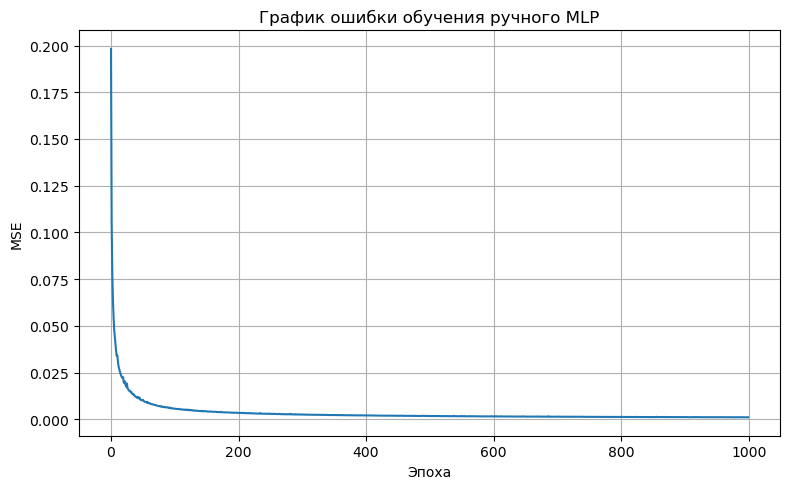

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


PATH = "selected_laptop_features_dataset.csv"


def print_section(title: str):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def print_metrics(y_true, y_pred, title):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}")


# ============================================
# ВЕРСИЯ 1 MLP 
# =============================================

def library_mlp_regressor(df: pd.DataFrame):
    print_section("ВЕРСИЯ 1. MLP-регрессор")

    X = df.drop("Price", axis=1)
    y = df["Price"]

    categorical_features = [c for c in ["Brand"] if c in X.columns]

    numeric_features = [
        c for c in X.columns
        if c not in categorical_features
    ]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", encoder, categorical_features)
        ]
    )

    model = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(
        y_train.to_numpy().reshape(-1, 1)
    ).ravel()

    pipeline.fit(X_train, y_train_scaled)

    y_pred_scaled = pipeline.predict(X_test)

    y_pred = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    print_metrics(
        y_test,
        y_pred,
        "Метрики качества библиотечной модели"
    )

    result = pd.DataFrame({
        "Real Price": y_test.to_numpy(),
        "Predicted Price": y_pred
    })

    print("\nПервые 10 предсказаний библиотечной модели:")
    print(result.head(10))

    trained_model = pipeline.named_steps["model"]

    if hasattr(trained_model, "loss_curve_"):
        plt.figure(figsize=(8, 5))
        plt.plot(trained_model.loss_curve_)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss")
        plt.title("График ошибки обучения sklearn MLPRegressor")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return pipeline


# ===================================================
# ВЕРСИЯ 2. РУЧНАЯ РЕАЛИЗАЦИЯ MLP 
# ===================================================

class ManualStandardScaler:
    def fit(self, data):
        self.mean = np.mean(data, axis=0)
        self.std = np.std(data, axis=0)

        self.std[self.std == 0] = 1

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return data * self.std + self.mean


class ManualMLPRegressor:
    def __init__(
        self,
        input_size,
        hidden1_size=64,
        hidden2_size=32,
        learning_rate=0.01,
        random_state=42
    ):
        np.random.seed(random_state)

        self.learning_rate = learning_rate

        # Веса между входным слоем и первым скрытым слоем
        self.W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden1_size))

        # Веса между первым и вторым скрытым слоем
        self.W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
        self.b2 = np.zeros((1, hidden2_size))

        # Веса между вторым скрытым слоем и выходом
        self.W3 = np.random.randn(hidden2_size, 1) * np.sqrt(2 / hidden2_size)
        self.b3 = np.zeros((1, 1))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        # Прямое распространение

        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        # Для регресси нв ыходе исп лин актив
        self.z3 = self.a2 @ self.W3 + self.b3

        return self.z3

    def backward(self, X, y, y_pred):
        
        # Обратное распространение ошибки

        m = X.shape[0]

        # Производная MSE по выходу 
        dz3 = 2 * (y_pred - y) / m

        dW3 = self.a2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.relu_derivative(self.z2)

        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Обновление весов  градиентом
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def fit(self, X, y, epochs=1000, batch_size=32):
        losses = []
        n_samples = X.shape[0]

        for epoch in range(epochs):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_pred_batch = self.forward(X_batch)
                self.backward(X_batch, y_batch, y_pred_batch)

            y_pred = self.forward(X)
            loss = np.mean((y_pred - y) ** 2)
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, MSE: {loss:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)


def manual_mlp_regressor(df: pd.DataFrame):
    print_section("ВЕРСИЯ 2. Ручная реализация MLP-регрессора")

    df_manual = df.copy()

    if "Brand" in df_manual.columns:
        df_manual = pd.get_dummies(df_manual, columns=["Brand"], drop_first=False)

    X = df_manual.drop("Price", axis=1).values.astype(float)
    y = df_manual["Price"].values.reshape(-1, 1).astype(float)

    x_scaler = ManualStandardScaler()
    y_scaler = ManualStandardScaler()

    x_scaler.fit(X)
    y_scaler.fit(y)

    X_scaled = x_scaler.transform(X)
    y_scaled = y_scaler.transform(y)

    np.random.seed(42)

    indices = np.arange(X_scaled.shape[0])
    np.random.shuffle(indices)

    test_size = int(0.2 * X_scaled.shape[0])

    test_indices = indices[:test_size]
    train_indices = indices[test_size:]

    X_train = X_scaled[train_indices]
    y_train = y_scaled[train_indices]

    X_test = X_scaled[test_indices]
    y_test = y_scaled[test_indices]

    model = ManualMLPRegressor(
        input_size=X_train.shape[1],
        hidden1_size=64,
        hidden2_size=32,
        learning_rate=0.01,
        random_state=42
    )

    losses = model.fit(
        X_train,
        y_train,
        epochs=1000,
        batch_size=32
    )

    y_pred_scaled = model.predict(X_test)

    y_test_original = y_scaler.inverse_transform(y_test)
    y_pred_original = y_scaler.inverse_transform(y_pred_scaled)

    print_metrics(
        y_test_original,
        y_pred_original,
        "Метрики качества ручной модели"
    )

    result = pd.DataFrame({
        "Real Price": y_test_original.flatten(),
        "Predicted Price": y_pred_original.flatten()
    })

    print("\nПервые 10 предсказаний ручной модели:")
    print(result.head(10))

    plt.figure(figsize=(8, 5))
    plt.plot(losses)
    plt.xlabel("Эпоха")
    plt.ylabel("MSE")
    plt.title("График ошибки обучения ручного MLP")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model





df = pd.read_csv(PATH)

print_section("Загрузка обработанного датасета")
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

library_model = library_mlp_regressor(df)

manual_model = manual_mlp_regressor(df)